# Tweet Classification Workshop
## Building an AI Factory: From Data to Deployment

This notebook demonstrates the complete pipeline of building a tweet sentiment classifier.

**What we'll build:** A classifier that determines if a tweet is positive, negative, or neutral.

**The 3 Components:**
1. **DATA ENGINE**: Load and prepare tweet data
2. **CLASSIFICATION MODEL**: Train a classification model
3. **DEPLOYMENT**: Make predictions on new tweets

## Setup: Install Required Libraries

In [93]:
# Install required packages
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud --break-system-packages -q


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [94]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## COMPONENT 1: DATA ENGINE
### Step 1: Create Sample Tweet Data

In a real AI Factory, data comes from:
- APIs (Twitter API, scrapers)
- User submissions
- Existing datasets

For this workshop, we'll create sample data that mimics real tweets.

In [95]:
# Sample tweet dataset with African context (built from three lists)
positive = [
    "Just got my first paycheck from my new job! Feeling blessed 🙏",
    "This jollof rice is absolutely amazing! Best I've ever had",
    "Congratulations to the team on winning! Well deserved victory",
    "Love seeing young entrepreneurs succeed in Lagos",
    "Finally got high-speed internet in my area. Game changer!",
    "The sunrise over Table Mountain never gets old. Beautiful!",
    "Proud of how far we've come as a nation",
    "This new mobile money service is so convenient",
    "Great customer service from @LocalBank today. Impressed!",
    "Can't wait for the festival this weekend! Going to be epic",
    "Loving this Afrobeats playlist. Fire tracks only 🔥",
    "My startup just got funding! Dreams do come true",
    "Best vacation ever! Kenya is stunning",
    "This movie was incredible. Highly recommend it!",
    "So grateful for my family and friends. Truly blessed",
    "The new highway has reduced my commute time by half. Excellent!",
    "Just received my scholarship letter! University here I come!",
    "This local restaurant serves the best suya in town",
    "Finally bought my first car. Hard work pays off!",
    "The stadium atmosphere was electric. What a match!",
    "Proud to see African tech startups getting global recognition",
    "This app is exactly what we needed. Brilliant solution!",
    "The community came together to build a new school. Unity!",
    "Best birthday celebration ever! Thanks to everyone who came",
    "Solar panels installed! No more generator expenses",
    "The new hospital has amazing facilities. Healthcare improving!",
    "Got promoted today! All the late nights were worth it",
    "This book is a masterpiece. Couldn't put it down",
    "The beach was pristine and peaceful. Perfect getaway",
    "My daughter graduated top of her class! So proud",
    "The new shopping mall has everything. Impressive development",
    "Volunteering at the orphanage was so rewarding. Will do it again",
    "The concert was phenomenal! Best live performance I've seen",
    "Finally debt-free! What a relief and achievement",
    "The food delivery was fast and hot. Great service!",
    "Won the hackathon! Our team worked so well together",
    "The sunrise safari was breathtaking. Nature at its finest",
    "My small business is thriving. Customers love the products",
    "The training program was excellent. Learned so much",
    "Clean water now available in our village. Life-changing!",
    "The new park is beautiful. Great for family outings",
    "Got accepted into my dream graduate program! Ecstatic!",
    "The local market has such fresh produce. Support local!",
    "Our football team made it to the finals! Historic moment",
    "The wedding was spectacular. Wishing them all the best",
    "This traditional dance performance was mesmerizing",
    "The mentorship program changed my career path. Grateful!",
    "Our village got connected to the national grid. Progress!",
    "The art exhibition showcased incredible local talent",
    "Just finished my first marathon! Feeling accomplished",
]
negative = [
    "Another power outage. This is getting ridiculous",
    "Waited 3 hours at the hospital and still no service. Unacceptable",
    "Traffic in Nairobi is a nightmare. Stuck for 2 hours now",
    "Customer service was terrible. Never shopping here again",
    "Internet is down again. How am I supposed to work?",
    "This corruption scandal is disgusting. We deserve better",
    "The prices keep going up but salaries stay the same. Struggling",
    "Disappointed with the election results. This country...",
    "Food poisoning from that restaurant. Worst experience ever",
    "Public transport is a mess. Always late, always crowded",
    "Can't believe they cancelled the event last minute. Waste of money",
    "This app keeps crashing. Absolutely frustrating",
    "Got scammed online. Be careful out there people",
    "The education system is failing our children",
    "Another broken promise from politicians. Not surprised anymore",
    "The roads are full of potholes. My car is falling apart",
    "Terrible service at the airport. Missed my flight",
    "The queue at the bank was 4 hours long. Ridiculous!",
    "Data prices are outrageous. How can anyone afford this?",
    "My package was stolen. Delivery service needs to improve",
    "The hospital ran out of basic medicine. This is a crisis",
    "Discrimination in the workplace needs to stop. Unacceptable",
    "The hotel was dirty and overpriced. Total ripoff",
    "Lost my job due to company downsizing. Times are tough",
    "The water supply has been cut for 3 days now. Suffering",
    "Police brutality incident today. When will this end?",
    "The exam was impossibly difficult. They set us up to fail",
    "My phone was stolen on the bus. Crime is out of control",
    "The landlord raised rent by 50%. Can't afford this anymore",
    "Constant fuel shortages. The queues never end",
    "The contractor abandoned our project. Money wasted",
    "Another bridge collapsed. Infrastructure is crumbling",
    "The insurance company refused my valid claim. Scammers",
    "Classrooms are overcrowded. 80 students per teacher!",
    "The stadium security was chaotic. Dangerous situation",
    "Government workers went on strike again. Nothing works",
    "The new tax is crippling small businesses. Unfair!",
    "Poor drainage caused flooding in our neighborhood again",
    "The concert was cancelled with no refund. Theft!",
    "Fake products everywhere in the market. Can't trust anything",
    "The university increased fees by 40%. Who can afford this?",
    "Air pollution is terrible. Everyone's getting sick",
    "The ATM has been empty for a week. Cash crisis continues",
    "Lost all my savings in a Ponzi scheme. Devastated",
    "The visa application process is deliberately frustrating",
    "Medical brain drain is real. All our doctors are leaving",
    "The power company hiked prices but service got worse",
    "Contaminated water made my family sick. Unacceptable",
    "The job interview was clearly rigged. Nepotism wins again",
    "Violent protests in the city center. Stay safe everyone",
]
neutral = [
    "Meeting scheduled for 2pm tomorrow at the usual spot",
    "The weather forecast says rain for the weekend",
    "New policy announced by the ministry today. Here's the link",
    "Coffee or tea? What's your preference?",
    "The match starts at 7pm. Who are you supporting?",
    "Just finished reading the news. Interesting developments",
    "The store opens at 9am on weekdays",
    "Population statistics released for 2024",
    "Here's a summary of today's parliamentary session",
    "The conference will be held in Accra next month",
    "Current exchange rate: 1 USD = 1650 Naira",
    "Flight to Johannesburg departs at 6:30am",
    "The app has been updated to version 2.3",
    "Survey results show 60% prefer option A",
    "New regulations take effect from next quarter",
    "The bank will be closed on Monday for a public holiday",
    "Presidential address scheduled for 8pm tonight",
    "Temperature today is expected to reach 28 degrees",
    "The report is due by Friday end of day",
    "Mobile network maintenance from 2am to 5am tomorrow",
    "Election results will be announced at noon",
    "The stadium capacity is 60,000 people",
    "New traffic rules come into effect next month",
    "The documentary airs on channel 5 at 9pm",
    "Market closes at 6pm on Saturdays",
    "The train schedule has been published online",
    "Inflation rate for Q3 was 7.2 percent",
    "The museum offers free entry on Sundays",
    "Registration deadline is October 15th",
    "The highway will be resurfaced in phases",
    "Latest GDP figures show 3.1% growth",
    "The library has extended hours during exam period",
    "Visa processing takes 2-3 weeks on average",
    "The building has 12 floors and 200 units",
    "Today's agenda includes three main items",
    "The currency was introduced in 1965",
    "Average rainfall this month is 80mm",
    "The project timeline is 18 months",
    "Voting stations open from 7am to 5pm",
    "The course consists of 6 modules",
    "Bus fare to the city center is 200 shillings",
    "The organization was founded in 1998",
    "Import duties vary between 5% and 25%",
    "The river is 420 kilometers long",
    "Standard delivery takes 3-5 business days",
    "The contract period is for 2 years",
    "There are 47 counties in the country",
    "The minimum wage is currently 15,000 per month",
    "School term starts on January 8th",
    "The summit will host delegates from 54 countries",
]
tweets = positive + negative + neutral
tweets_data = {'text': tweets, 'sentiment': ['positive']*len(positive) + ['negative']*len(negative) + ['neutral']*len(neutral)}

# Create DataFrame
df = pd.DataFrame(tweets_data)

print("Dataset created!")
print(f"Total tweets: {len(df)}")
print("\nFirst few tweets:")
df.head()

Dataset created!
Total tweets: 150

First few tweets:


,text,sentiment
0,Just got my first paycheck from my new job! Fe...,positive
1,This jollof rice is absolutely amazing! Best I...,positive
2,Congratulations to the team on winning! Well d...,positive
3,Love seeing young entrepreneurs succeed in Lagos,positive
4,Finally got high-speed internet in my area. Ga...,positive


### Step 2: Explore the Data
Understanding your data is crucial in the AI Factory

Sentiment Distribution:
sentiment
positive    50
negative    50
neutral     50
Name: count, dtype: int64

Percentages:
sentiment
positive    33.333333
negative    33.333333
neutral     33.333333
Name: proportion, dtype: float64


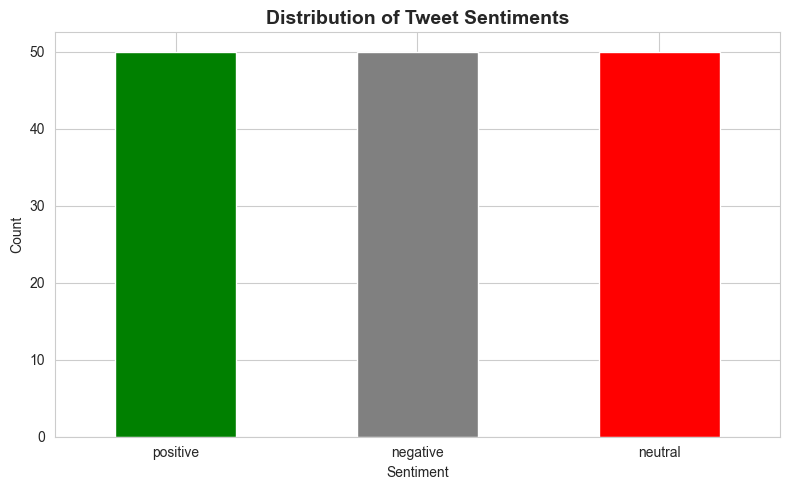

In [96]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

# Visualize distribution
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'gray', 'red'])
plt.title('Distribution of Tweet Sentiments', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Step 3: Clean and Prepare the Data
Real-world text data is messy. We need to clean it!

In [97]:
def clean_tweet(text):
    """Clean tweet text for processing"""
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags (keep the text)
    text = re.sub(r'#', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_tweet)

# Show before and after
print("Before and After Cleaning:")
print("="*80)
for i in range(3):
    print(f"\nOriginal: {df['text'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i]}")
    print("-"*80)

Before and After Cleaning:

Original: Just got my first paycheck from my new job! Feeling blessed 🙏
Cleaned:  just got my first paycheck from my new job! feeling blessed 🙏
--------------------------------------------------------------------------------

Original: This jollof rice is absolutely amazing! Best I've ever had
Cleaned:  this jollof rice is absolutely amazing! best i've ever had
--------------------------------------------------------------------------------

Original: Congratulations to the team on winning! Well deserved victory
Cleaned:  congratulations to the team on winning! well deserved victory
--------------------------------------------------------------------------------


## COMPONENT 2: CLASSIFICATION MODEL 
### Step 4: Split Data into Training and Testing Sets

We need to:
- **Train** the model on some data
- **Test** it on unseen data to check if it really works

In [98]:
# Split data: 80% training, 20% testing
X = df['cleaned_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} tweets")
print(f"Testing set: {len(X_test)} tweets")
print("\nTraining set distribution:")
print(y_train.value_counts())

Training set: 120 tweets
Testing set: 30 tweets

Training set distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64


### Step 5: Convert Text to Numbers (Feature Extraction)

Computers don't understand wordsthey understand numbers!
We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to convert text to numerical features.

In [99]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=100,  # Use top 100 most important words
    ngram_range=(1, 2),  # Use single words and pairs of words
    min_df=1  # Word must appear at least once
)

# Fit and transform training data
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

print(f"Text converted to numerical features!")
print(f"Feature matrix shape: {X_train_vectors.shape}")
print(f"({X_train_vectors.shape[0]} tweets × {X_train_vectors.shape[1]} features)")

# Show some important words
feature_names = vectorizer.get_feature_names_out()
print(f"\nSome features (words): {list(feature_names[:20])}")

Text converted to numerical features!
Feature matrix shape: (120, 100)
(120 tweets × 100 features)

Some features (words): ['again', 'all', 'and', 'app', 'are', 'at', 'at the', 'bank', 'be', 'been', 'best', 'blessed', 'bus', 'business', 'but', 'by', 'came', 'can', 'car', 'come']


### Step 6: Train the Model

Now we teach the AI to recognize patterns!
We'll train two different models and compare them.

In [100]:
# Model 1: Naive Bayes (Simple, fast)
print("Training Model 1: Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train_vectors, y_train)
print(" Naive Bayes trained!")

# Model 2: Logistic Regression (More sophisticated)
print("\nTraining Model 2: Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vectors, y_train)
print("Logistic Regression trained!")

Training Model 1: Naive Bayes...
 Naive Bayes trained!

Training Model 2: Logistic Regression...
Logistic Regression trained!


### Step 7: Evaluate the Models

How well do our models perform on unseen data?

In [101]:
# Make predictions
nb_predictions = nb_model.predict(X_test_vectors)
lr_predictions = lr_model.predict(X_test_vectors)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)
print(f"\nNaive Bayes Accuracy:        {nb_accuracy*100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

# Choose the better model
if lr_accuracy >= nb_accuracy:
    best_model = lr_model
    best_predictions = lr_predictions
    best_name = "Logistic Regression"
else:
    best_model = nb_model
    best_predictions = nb_predictions
    best_name = "Naive Bayes"

print(f"\n🏆 Best Model: {best_name}")

MODEL PERFORMANCE COMPARISON

Naive Bayes Accuracy:        73.33%
Logistic Regression Accuracy: 76.67%

🏆 Best Model: Logistic Regression


In [102]:
# Detailed classification report
print(f"\nDetailed Performance Report for {best_name}:")
print("="*60)
print(classification_report(y_test, best_predictions, target_names=['negative', 'neutral', 'positive']))


Detailed Performance Report for Logistic Regression:
              precision    recall  f1-score   support

    negative       0.80      0.40      0.53        10
     neutral       0.75      0.90      0.82        10
    positive       0.77      1.00      0.87        10

    accuracy                           0.77        30
   macro avg       0.77      0.77      0.74        30
weighted avg       0.77      0.77      0.74        30



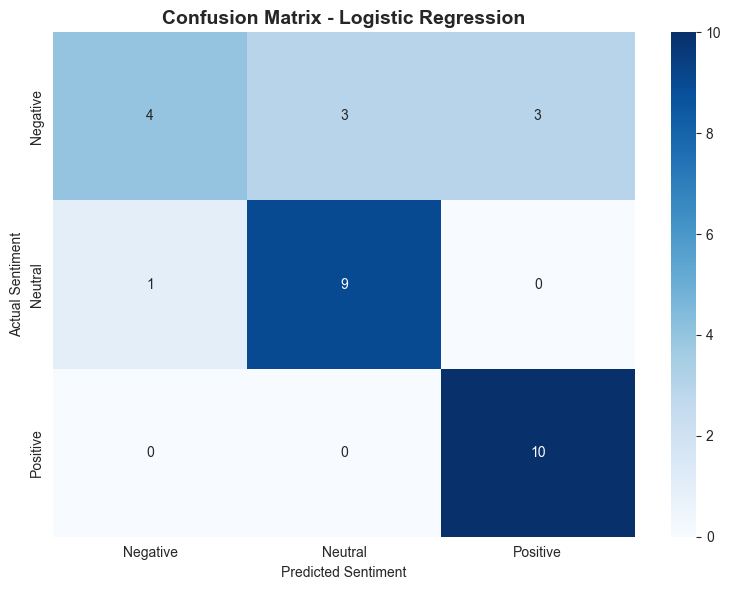


How to read this matrix:
- Diagonal cells (dark blue) = Correct predictions
- Off-diagonal cells = Mistakes


In [103]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title(f'Confusion Matrix - {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

print("\nHow to read this matrix:")
print("- Diagonal cells (dark blue) = Correct predictions")
print("- Off-diagonal cells = Mistakes")

##  COMPONENT 3: DEPLOYMENT
### Step 8: Make Predictions on New Tweets

This is where the AI Factory delivers value—classifying new, unseen tweets!

In [104]:
def predict_sentiment(tweet_text):
    """Predict sentiment of a new tweet"""
    # Clean the tweet
    cleaned = clean_tweet(tweet_text)
    # Convert to features
    features = vectorizer.transform([cleaned])
    # Make prediction
    prediction = best_model.predict(features)[0]
    # Get confidence scores
    probabilities = best_model.predict_proba(features)[0]
    
    return prediction, probabilities

# Test with new tweets
new_tweets = [
    "This new policy is absolutely terrible for small businesses",
    "Just launched my app! Excited to see how users respond",
    "The meeting has been rescheduled to Thursday at 3pm",
    "Power has been out for 6 hours. Completely unacceptable!",
    "Amazing performance by the team today! So proud of everyone"
]

print("="*80)
print("TESTING THE AI FACTORY ON NEW TWEETS")
print("="*80)

for tweet in new_tweets:
    sentiment, probs = predict_sentiment(tweet)
    confidence = max(probs) * 100
    
    # Color code the output
    color_map = {'positive': '🟢', 'negative': '🔴', 'neutral': '⚪'}
    
    print(f"\nTweet: {tweet}")
    print(f"Prediction: {color_map[sentiment]} {sentiment.upper()} (Confidence: {confidence:.1f}%)")
    print(f"Probabilities: Neg={probs[0]:.2f}, Neu={probs[1]:.2f}, Pos={probs[2]:.2f}")
    print("-"*80)

TESTING THE AI FACTORY ON NEW TWEETS

Tweet: This new policy is absolutely terrible for small businesses
Prediction: 🔴 NEGATIVE (Confidence: 43.4%)
Probabilities: Neg=0.43, Neu=0.25, Pos=0.31
--------------------------------------------------------------------------------

Tweet: Just launched my app! Excited to see how users respond
Prediction: 🟢 POSITIVE (Confidence: 45.5%)
Probabilities: Neg=0.30, Neu=0.24, Pos=0.45
--------------------------------------------------------------------------------

Tweet: The meeting has been rescheduled to Thursday at 3pm
Prediction: ⚪ NEUTRAL (Confidence: 55.5%)
Probabilities: Neg=0.21, Neu=0.56, Pos=0.24
--------------------------------------------------------------------------------

Tweet: Power has been out for 6 hours. Completely unacceptable!
Prediction: 🔴 NEGATIVE (Confidence: 55.7%)
Probabilities: Neg=0.56, Neu=0.28, Pos=0.16
--------------------------------------------------------------------------------

Tweet: Amazing performance by the t

### Step 9: Interactive Prediction

Try your own tweets!

## Summary: The AI Factory Pipeline

### What We Built:

1. **DATA ENGINE** 
   - Created and cleaned tweet dataset
   - Explored data distribution
   - Converted text to numerical features

2. **MODEL** 
   - Trained two different models
   - Evaluated performance
   - Selected the best model

3. **DEPLOYMENT** 
   - Created prediction function
   - Tested on new tweets
   - Built interactive classifier

### Key Metrics:
- **Accuracy**: How often the model is correct
- **Precision**: Of the tweets predicted as positive, how many actually are?
- **Recall**: Of all positive tweets, how many did we find?

### Next Steps for Production:
- Collect more training data
- Handle class imbalance
- Add more languages (Swahili, Yoruba, etc.)
- Deploy as API or web app
- Monitor performance over time